# Example: Predator-Prey dynamics

Here, we apply the constant minibatch and adaptive minibatch SMC ABC algorithms to estimate parameters for predator prey dynamics given by stochastic Lotka-Volterra with logistic growth in the prey population. For speed, we apply a vectorized Tau Leaping algorithm, limiting simulation time considerably for off-particle choices. The dynamics are given by the reaction network: 

In [1]:
#Inference classes
from smc_abc import smc_abc_iterator as abc_iter
import smc_abc_utils as utils
import smc_abc_schemes as schemes

#Simulator classes
import lotka_volterra as lv

from numba import njit

#Support
import numpy as np
from matplotlib import pyplot as plt


cwd appended to system path


array([[-0.0128232 ,  6.00767336,  6.00287841,  9.95940017,  5.25814578,
         5.14422908,  0.        ,  0.90288697,  0.90781707,  0.6576251 ,
         0.66770552,  0.32724697,  0.33447588],
       [ 0.01995572,  5.99519862,  6.00589642,  9.13277887,  5.42189844,
         5.4901415 ,  0.        ,  0.89968591,  0.90045258,  0.66870349,
         0.65625238,  0.36772124,  0.31503798]])

0


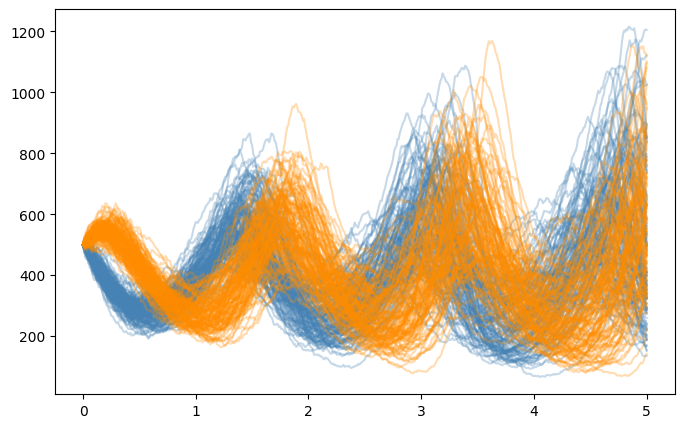

In [2]:
## Setup and tau leaping example
sample_size = 128
alpha,beta,gamma,delta = 4,0.01,4,1
t_max = 5
dt = 0.01
#ic = np.random.uniform(400,600,size=(sample_size,2))
ic = np.random.choice(1,(sample_size,2)) + 500

times,ts = lv.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt)

fig,ax = plt.subplots(figsize = (8,5))
ax.plot(times,ts[:,:,0].T,color = 'steelblue',alpha = 0.3);
ax.plot(times,ts[:,:,1].T,color = 'darkorange',alpha = 0.3);


data = ts

print(np.sum(np.any(np.any(data == 0,axis=1),axis=1)))

data

In [3]:
# Summary Statistics: predator prey model
@njit
def batch_corr_single(a, b, eps=1e-8):
    """Correlation for a single pair of vectors (numba compatible)"""
    ma = a - np.mean(a)
    mb = b - np.mean(b)
    num = np.sum(ma * mb)
    den = np.sqrt(np.sum(ma**2) * np.sum(mb**2))
    return num / (den + eps)

#general parameters
num_particles = 500
cores = 4
@njit
def stats_func_lv(x, max_lag=3, step_size=10):
    n_replicates = x.shape[0]
    n_timesteps = x.shape[1]
    eps = 1e-8
    
    # Pre-calculate number of features
    # 1 (ext_ind) + 5 (logs) + 1 (cross-corr) + 2 * max_lag (auto-corrs)
    num_features = 7 + (2 * max_lag)
    out = np.zeros((n_replicates, num_features))
    
    for i in range(n_replicates):
        r_full = x[i, :, 0]
        f_full = x[i, :, 1]
        
        # --- 1. Find Extinction Index ---
        ext_ind = n_timesteps # Default to full length
        for t in range(n_timesteps):
            if r_full[t] <= 0 or f_full[t] <= 0:
                ext_ind = t + 1 # Include the first zero
                break
        
        # Slice the data for this replicate
        r = r_full[:ext_ind]
        f = f_full[:ext_ind]
        
        # --- 2. Base Moments ---
        #out[i, 0] = float(ext_ind)
        out[i, 0] = batch_corr_single(r, f, eps)
        out[i, 1] = np.log(np.mean(r) + eps)
        out[i, 2] = np.log(np.mean(f) + eps)
        out[i, 3] = np.log(np.var(r) + eps)
        out[i, 4] = np.log(np.min(r) + eps)
        out[i, 5] = np.log(np.min(f) + eps)
        #out[i, 6] = batch_corr_single(r, f, eps)
        
        # --- 3. Autocorrelation Lags ---
        # Note: If ext_ind < lag, these will be NaNs. 
        # Usually handled by the ABC or Mahalanobis later.
        for l_idx in range(1, max_lag + 1):
            lag = l_idx * step_size
            col_r = 7 + (l_idx - 1) * 2
            col_f = col_r + 1
            
            if ext_ind > lag:
                out[i, col_r] = batch_corr_single(r[:-lag], r[lag:], eps)
                out[i, col_f] = batch_corr_single(f[:-lag], f[lag:], eps)
            else:
                out[i, col_r] = np.nan
                out[i, col_f] = np.nan
    return out

def stats_func(x,y,sf=stats_func_lv):
    return x,y

s_data = stats_func_lv(data)
N_stats = s_data.shape[1]
def model(p, Bi, num_reps=3):
    alpha, beta, gamma = p
    s_sim = np.zeros((Bi.shape[0],N_stats))
    for _ in range(3):
        _, sim = lv.tau_leaping(ic[Bi], t_max,alpha, beta, gamma, delta,dt=dt)
        s_sim += stats_func_lv(sim)
    s_sim /= num_reps
    s_obs = s_data[Bi]
    return s_sim, s_obs


prior = utils.uniform_prior([[0.0,10.0],[0.0,0.05],[0.0,10.0]])

init_params = {
    'data': s_data,
    'model': model,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles':num_particles,
    'cores':cores
}

Running benchmarks...
Batch 1: 0.000644 sec
Batch 2: 0.001074 sec
Batch 4: 0.001998 sec
Batch 8: 0.003699 sec
Batch 16: 0.007305 sec
Batch 32: 0.014616 sec
Batch 64: 0.029065 sec
Batch 128: 0.057317 sec
Average increase in seconds per sample: 0.00044533102357360936


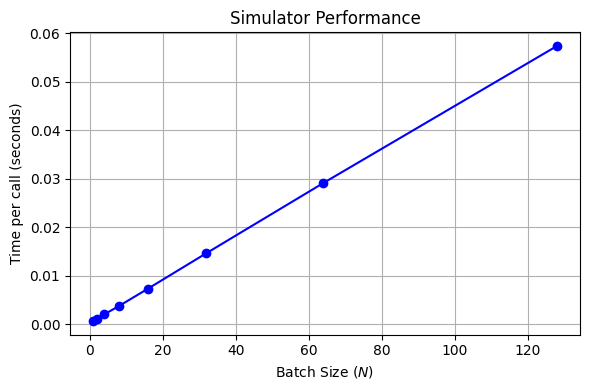

In [27]:
utils.benchmark_time([1,2,4,8,16,32,64,128],lambda n: model([alpha,beta,gamma],np.random.choice(sample_size,n)))

In [ ]:
est = schemes.constant_init(init_params,[8])
for i in range(3):
    schemes.constant_loop(est)
# while (est.snr > 2) and (est.acceptance_rate > 0.02):
#     schemes.constant_loop(est)

Generation: 1. Batch Size: 8. Acceptance Rate: 0.467. Step time: 11.437. Total time 11.437. post-filter threshold: 25.8842. ESS: 500.00. Log HDPR vol: 0.479
Estimated v_total = 233.035. Noise: v/n = 29.129. Noise floor estimate: v/N = 1.821. Estimated c = 0.202. SNR: eps^2 / (v/n) = 23.001. Time per sim: 0.005
Generation: 2. Batch Size: 8. Acceptance Rate: 0.533. Step time: 1.849. Total time 13.286. post-filter threshold: 17.2279. ESS: 488.37. Log HDPR vol: -0.314
Estimated v_total = 137.960. Noise: v/n = 17.245. Noise floor estimate: v/N = 1.078. Estimated c = 0.233. SNR: eps^2 / (v/n) = 17.211. Time per sim: 0.001
Generation: 3. Batch Size: 8. Acceptance Rate: 0.366. Step time: 2.416. Total time 15.703. post-filter threshold: 13.2899. ESS: 487.66. Log HDPR vol: -1.134
Estimated v_total = 79.473. Noise: v/n = 9.934. Noise floor estimate: v/N = 0.621. Estimated c = 0.230. SNR: eps^2 / (v/n) = 17.779. Time per sim: 0.001
Generation: 4. Batch Size: 8. Acceptance Rate: 0.323. Step time: 2

In [40]:
est = schemes.constant_init(init_params,[32])

while (est.snr > 2) and (est.acceptance_rate > 0.02):
    schemes.constant_loop(est)

Generation: 1. Batch Size: 32. Acceptance Rate: 0.683. Step time: 2.948. Total time 2.948. post-filter threshold: 15.2381. ESS: 500.00. Log HDPR vol: 0.755
Estimated v_total = 35.587. Noise: v/n = 1.112. Noise floor estimate: v/N = 0.278. Estimated c = 0.060. SNR: eps^2 / (v/n) = 208.797. Time per sim: 0.002
Generation: 2. Batch Size: 32. Acceptance Rate: 0.554. Step time: 5.723. Total time 8.670. post-filter threshold: 10.2185. ESS: 483.58. Log HDPR vol: 0.225
Estimated v_total = 28.914. Noise: v/n = 0.904. Noise floor estimate: v/N = 0.226. Estimated c = 0.081. SNR: eps^2 / (v/n) = 115.562. Time per sim: 0.003
Generation: 3. Batch Size: 32. Acceptance Rate: 0.379. Step time: 7.799. Total time 16.470. post-filter threshold: 7.6691. ESS: 485.09. Log HDPR vol: -0.710
Estimated v_total = 24.603. Noise: v/n = 0.769. Noise floor estimate: v/N = 0.192. Estimated c = 0.099. SNR: eps^2 / (v/n) = 76.499. Time per sim: 0.003
Generation: 4. Batch Size: 32. Acceptance Rate: 0.304. Step time: 9.58

In [42]:
est = schemes.constant_init(init_params,[64])

while (est.snr > 2) and (est.acceptance_rate > 0.02):
    schemes.constant_loop(est)

Generation: 1. Batch Size: 64. Acceptance Rate: 0.635. Step time: 15.149. Total time 15.149. post-filter threshold: 16.0375. ESS: 500.00. Log HDPR vol: 0.823
Estimated v_total = 39.383. Noise: v/n = 0.615. Noise floor estimate: v/N = 0.308. Estimated c = 0.035. SNR: eps^2 / (v/n) = 417.966. Time per sim: 0.010
Generation: 2. Batch Size: 64. Acceptance Rate: 0.546. Step time: 10.520. Total time 25.669. post-filter threshold: 10.7752. ESS: 483.68. Log HDPR vol: 0.257
Estimated v_total = 34.955. Noise: v/n = 0.546. Noise floor estimate: v/N = 0.273. Estimated c = 0.048. SNR: eps^2 / (v/n) = 212.582. Time per sim: 0.006
Generation: 3. Batch Size: 64. Acceptance Rate: 0.363. Step time: 14.597. Total time 40.267. post-filter threshold: 7.7755. ESS: 486.00. Log HDPR vol: -0.599
Estimated v_total = 26.679. Noise: v/n = 0.417. Noise floor estimate: v/N = 0.208. Estimated c = 0.059. SNR: eps^2 / (v/n) = 145.034. Time per sim: 0.005
Generation: 4. Batch Size: 64. Acceptance Rate: 0.301. Step time

In [4]:
est = schemes.fvc_init(init_params,[2,None,1.0])

while (est.snr > 2) and (est.acceptance_rate > 0.02):
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 0.713. Step time: 10.938. Total time 10.938. post-filter threshold: 127.6740. ESS: 500.00. Log HDPR vol: 0.915
Estimated v_total = 2109.148. Noise: v/n = 1054.574. Noise floor estimate: v/N = 16.478. Estimated c = 0.252. SNR: eps^2 / (v/n) = 15.457. Time per sim: 0.008
Automatic c selection: c = 0.25235760381557903
New hyperparameter set: [2, np.float64(0.25235760381557903), 1.0]
Estimated v_total with ema: 2109.148. Batch size update: 2
Generation: 2. Batch Size: 2. Acceptance Rate: 0.593. Step time: 1.269. Total time 12.208. post-filter threshold: 58.5696. ESS: 481.26. Log HDPR vol: 0.204
Estimated v_total = 544.247. Noise: v/n = 272.123. Noise floor estimate: v/N = 4.252. Estimated c = 0.279. SNR: eps^2 / (v/n) = 12.606. Time per sim: 0.001
Estimated v_total with ema: 544.247. Batch size update: 2
Generation: 3. Batch Size: 2. Acceptance Rate: 0.489. Step time: 1.095. Total time 13.302. post-filter threshold: 31.9696. ESS: 489.38. Log H

KeyboardInterrupt: 

In [34]:
est = schemes.fvc_init(init_params,[2,None,1.0])

while (est.snr > 2) and (est.acceptance_rate > 0.02):
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 0.598. Step time: 0.680. Total time 0.680. post-filter threshold: 33.9163. ESS: 500.00. Log HDPR vol: 0.820
Estimated v_total = 264.970. Noise: v/n = 132.485. Noise floor estimate: v/N = 2.070. Estimated c = 0.337. SNR: eps^2 / (v/n) = 8.683. Time per sim: 0.000
Automatic c selection: c = 0.3367096349883062
New hyperparameter set: [2, np.float64(0.3367096349883062), 1.0]
Estimated v_total with ema: 264.970. Batch size update: 2
Generation: 2. Batch Size: 2. Acceptance Rate: 0.535. Step time: 0.879. Total time 1.559. post-filter threshold: 21.4861. ESS: 484.93. Log HDPR vol: 0.022
Estimated v_total = 107.404. Noise: v/n = 53.702. Noise floor estimate: v/N = 0.839. Estimated c = 0.338. SNR: eps^2 / (v/n) = 8.597. Time per sim: 0.000
Estimated v_total with ema: 107.404. Batch size update: 2
Generation: 3. Batch Size: 2. Acceptance Rate: 0.409. Step time: 1.027. Total time 2.586. post-filter threshold: 15.7976. ESS: 486.36. Log HDPR vol: -0.82

KeyboardInterrupt: 

In [25]:
#general parameters
num_particles = 500
cores = 4

#Stats function
def batch_corr(a, b):
    """Vectorized correlation between rows of a and b"""
    ma = a - np.mean(a, axis=1, keepdims=True)
    mb = b - np.mean(b, axis=1, keepdims=True)
    
    num = np.sum(ma * mb, axis=1)
    den = np.sqrt(np.sum(ma**2, axis=1) * np.sum(mb**2, axis=1))
    return num / (den + 1e-8)

eps = 1e-8
def stats_func_lv(x, max_lag=3, step_size=10):
    r = x[:, :, 0]
    f = x[:, :, 1]
    
    # 1. Base Moments (Per-particle)
    stats_list = [
        np.log(np.mean(r, axis=1) + eps),
        np.log(np.mean(f, axis=1) + eps),
        np.log(np.var(r, axis=1) + eps),
        np.log(np.min(r, axis=1) + eps),
        np.log(np.min(f, axis=1) + eps),
        batch_corr(r, f) # Cross-correlation
    ]

    # 2. Add multiple Autocorrelation lags
    for i in range(1, max_lag + 1):
        lag = i * step_size # e.g., lags of 10, 20, 30, 40, 50 steps
        stats_list.append(batch_corr(r[:, :-lag], r[:, lag:]))
        stats_list.append(batch_corr(f[:, :-lag], f[:, lag:]))

    return np.column_stack(stats_list)
def stats_func(x,y,sf=stats_func_lv):
    return sf(x),sf(y)

#three replicates is fairly standard
s_obs_all_raw = stats_func_lv(data)
def model(p, Bi, num_reps=3):
    alpha, beta, gamma = p
    Bi_rep = np.repeat(Bi, num_reps)
    
    _, sim = lv.tau_leaping(
        ic[Bi_rep], t_max,
        alpha, beta, gamma, delta,
        dt=dt, K=K
    )
    s_sim = stats_func_lv(sim)
    s_obs = s_obs_all_raw[Bi_rep] 
    
    return s_sim, s_obs


def stats_func(x,y,sf=stats_func_lv):
    return x,y

prior = utils.uniform_prior([[0.0,10.0],[0.0,0.05],[0.0,10.0]])

s_data = stats_func_lv(data)

init_params = {
    'data': s_data,
    'model': model,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles':num_particles,
    'cores':cores
}
np.var(s_data,axis=0)

array([1.04026320e-01, 1.40695117e-01, 4.06372967e-01, 6.86336994e+00,
       4.43377675e+00, 1.76738264e-02, 1.04046980e-03, 1.17032034e-03,
       5.70863494e-03, 1.00597430e-02, 1.13095424e-02, 2.81326929e-02])

In [65]:
est = schemes.constant_init(init_params,[32])

tlist_c = []
# while (est.snr > 2) and (est.acceptance_rate > 0.02):
for _ in range(16):
    schemes.constant_loop(est)
    tlist_c.append(est.total_time)
    if est.acceptance_rate < 0.001:
        break

Generation: 1. Batch Size: 32. Acceptance Rate: 0.733. Step time: 10.345. Total time 10.345. post-filter threshold: 12.5120. ESS: 300.00. Log HDPR vol: 0.748
Estimated v_total = 62.037. Noise: v/n = 1.939. Noise floor estimate: v/N = 0.061. Estimated c = 0.110. SNR: eps^2 / (v/n) = 80.751. Time per sim: 0.013
Generation: 2. Batch Size: 32. Acceptance Rate: 0.557. Step time: 2.540. Total time 12.886. post-filter threshold: 8.4608. ESS: 286.85. Log HDPR vol: 0.197
Estimated v_total = 43.163. Noise: v/n = 1.349. Noise floor estimate: v/N = 0.042. Estimated c = 0.135. SNR: eps^2 / (v/n) = 53.072. Time per sim: 0.002
Generation: 3. Batch Size: 32. Acceptance Rate: 0.391. Step time: 3.374. Total time 16.260. post-filter threshold: 5.8231. ESS: 289.79. Log HDPR vol: -0.608
Estimated v_total = 36.314. Noise: v/n = 1.135. Noise floor estimate: v/N = 0.035. Estimated c = 0.180. SNR: eps^2 / (v/n) = 29.880. Time per sim: 0.002
Generation: 4. Batch Size: 32. Acceptance Rate: 0.299. Step time: 3.42

KeyboardInterrupt: 

In [27]:
est = schemes.fvc_init(init_params,[2,None,1.0])

tlist_a = []
# while (est.snr > 2) and (est.acceptance_rate > 0.02):
for i in range(16):
    schemes.fvc_loop(est)
    tlist_a.append(est.total_time)
    if est.acceptance_rate < 0.001:
        break

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 1.541. Total time 1.541. post-filter threshold: 111.1784. ESS: 300.00. Log HDPR vol: 1.049
Estimated v = 3673.499. Noise: v/n = 1836.749. v/N = 3.587. Estimated c = 0.385. SNR: eps^2 / (v/n) = 6.730. Time per sim: 0.003
Automatic c selection: c = 0.38510561958520273
New hyperparameter set: [np.int64(2), np.float64(0.38510561958520273), 1.0]
Batch size: 2.0
Generation: 2. Batch Size: 2. Acceptance Rate: 0.681. Step time: 1.772. Total time 3.313. post-filter threshold: 48.9439. ESS: 286.09. Log HDPR vol: 0.555
Estimated v = 212.705. Noise: v/n = 106.353. v/N = 0.208. Estimated c = 0.210. SNR: eps^2 / (v/n) = 22.524. Time per sim: 0.002
Batch size: 2.0
Generation: 3. Batch Size: 2. Acceptance Rate: 0.528. Step time: 1.945. Total time 5.257. post-filter threshold: 32.0591. ESS: 291.91. Log HDPR vol: -0.093
Estimated v = 63.727. Noise: v/n = 31.863. v/N = 0.062. Estimated c = 0.176. SNR: eps^2 / (v/n) = 32.256. Time per sim: 0

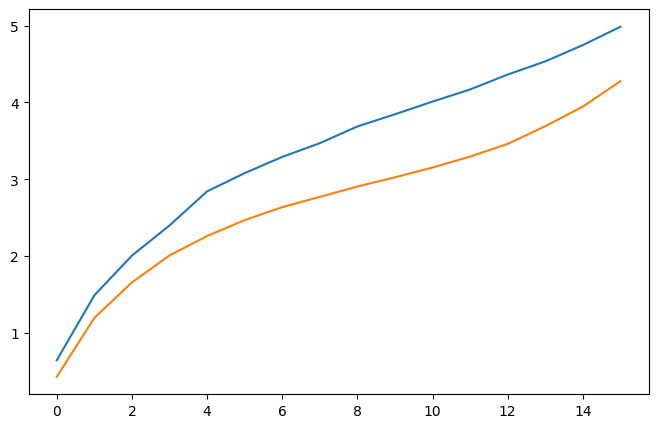

In [29]:
fig,ax = plt.subplots(figsize = (8,5))
ax.plot(np.log(tlist_c),label = 'Constant batch size')
ax.plot(np.log(tlist_a),label = 'Adaptive batch size')

### Replicates


In [9]:
## Setup and tau leaping example
sample_size = 128
alpha,beta,gamma,delta = 4,0.01,4,1
K = 1000
t_max = 5
dt = 0.01
ic = np.random.uniform(400,600,size=(sample_size,2))

times,data = lv.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt)

print(np.sum(np.any(np.any(data == 0,axis=1),axis=1)))

0


In [10]:
from numba import njit

In [ ]:
#general parameters
num_particles = 500
cores = 4

#Stats function
def batch_corr(a, b):
    """Vectorized correlation between rows of a and b"""
    ma = a - np.mean(a, axis=1, keepdims=True)
    mb = b - np.mean(b, axis=1, keepdims=True)
    
    num = np.sum(ma * mb, axis=1)
    den = np.sqrt(np.sum(ma**2, axis=1) * np.sum(mb**2, axis=1))
    return num / (den + 1e-8)

eps = 1e-8
def stats_func_lv(x, max_lag=3, step_size=10):
    r = x[:, :, 0]
    f = x[:, :, 1]
    
    # 1. Base Moments (Per-particle)
    stats_list = [
        np.log(np.mean(r, axis=1) + eps),
        np.log(np.mean(f, axis=1) + eps),
        np.log(np.var(r, axis=1) + eps),
        np.log(np.min(r, axis=1) + eps),
        np.log(np.min(f, axis=1) + eps),
        batch_corr(r, f) # Cross-correlation
    ]

    # 2. Add multiple Autocorrelation lags
    for i in range(1, max_lag + 1):
        lag = i * step_size # e.g., lags of 10, 20, 30, 40, 50 steps
        stats_list.append(batch_corr(r[:, :-lag], r[:, lag:]))
        stats_list.append(batch_corr(f[:, :-lag], f[:, lag:]))

    return np.column_stack(stats_list)
def stats_func(x,y,sf=stats_func_lv):
    return sf(x),sf(y)

#three replicates is fairly standard
s_obs_all_raw = stats_func_lv(data)
def model(p, Bi, num_reps=3):
    alpha, beta, gamma = p
    Bi_rep = np.repeat(Bi, num_reps)
    
    _, sim = lv.tau_leaping(
        ic[Bi_rep], t_max,
        alpha, beta, gamma, delta,
        dt=dt
    )
    s_sim = stats_func_lv(sim)
    s_obs = s_obs_all_raw[Bi_rep] 
    
    return s_sim, s_obs


def stats_func(x,y,sf=stats_func_lv):
    return x,y

prior = utils.uniform_prior([[0.0,10.0],[0.0,0.05],[0.0,10.0]])

s_data = stats_func_lv(data)

init_params = {
    'data': s_data,
    'model': model,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles':num_particles,
    'cores':cores
}
np.var(s_data,axis=0)

array([1.13617513e-03, 1.02669542e-03, 7.54569746e-01, 1.77223276e-01,
       2.07197411e-01, 2.56206574e-03, 2.50784258e-04, 1.77995774e-04,
       1.85946907e-03, 1.61749484e-03, 4.28551735e-03, 4.54762364e-03])

(128, 12)

Running benchmarks...
Batch 1: 0.000941 sec
Batch 2: 0.001435 sec
Batch 10: 0.005567 sec
Batch 50: 0.026015 sec
Batch 100: 0.066332 sec
Average increase in seconds per sample: 0.0005820161227311473


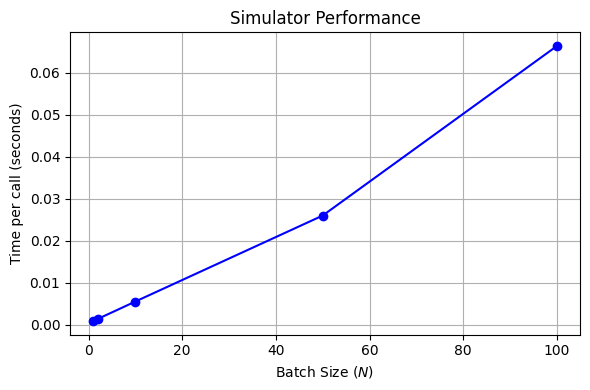

In [5]:
def func(n):
    return model([alpha,beta,gamma],np.random.choice(sample_size,n))

utils.benchmark_time([1,2,10,50,100],func)

In [6]:
est = schemes.fvc_kn_init(init_params)

while est.snr > 2 and est.acceptance_rate > 0.02:
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 7.261. Total time 7.261. post-filter threshold: 98.2572. ESS: 300.00. Log HDPR vol: 1.008
Estimated v = 1482.183. Noise: v/n = 741.091. v/N = 11.580. Estimated c = 0.275. SNR: eps^2 / (v/n) = 13.027. Time per sim: 0.012
Automatic c selection: c = 0.19282452900434363
New hyperparameter set: [2, np.float64(0.19282452900434363), 1.0]
Within-batch variance: 1.482e+03. Within-replicate variance: 2.558e+03. Batch size: 2.0. Reps: 2.0
Generation: 2. Batch Size: 2. Acceptance Rate: 0.640. Step time: 0.690. Total time 7.951. post-filter threshold: 45.1863. ESS: 290.35. Log HDPR vol: 0.505
Estimated v = 305.945. Noise: v/n = 152.973. v/N = 2.390. Estimated c = 0.272. SNR: eps^2 / (v/n) = 13.348. Time per sim: 0.001
Within-batch variance: 3.059e+02. Within-replicate variance: 5.115e+02. Batch size: 2.0. Reps: 2.0
Generation: 3. Batch Size: 2. Acceptance Rate: 0.511. Step time: 0.697. Total time 8.648. post-filter threshold: 31.4474.

In [7]:
est = schemes.fvc_kn2_init(init_params)

while est.snr > 2 and est.acceptance_rate > 0.02:
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 0.460. Total time 0.460. post-filter threshold: 116.6370. ESS: 300.00. Log HDPR vol: 1.040
Estimated v = 1909.659. Noise: v/n = 954.829. v/N = 14.919. Estimated c = 0.263. SNR: eps^2 / (v/n) = 14.248. Time per sim: 0.001
Automatic c selection: c = 0.1843815540492167
New hyperparameter set: [2, np.float64(0.1843815540492167), 1.0]
Within-batch variance: 1.910e+03. Within-replicate variance: 2.489e+03. Batch size: 2.0. Reps: 2.0
Generation: 2. Batch Size: 2. Acceptance Rate: 0.691. Step time: 0.601. Total time 1.061. post-filter threshold: 53.5449. ESS: 288.15. Log HDPR vol: 0.440
Estimated v = 309.684. Noise: v/n = 154.842. v/N = 2.419. Estimated c = 0.231. SNR: eps^2 / (v/n) = 18.516. Time per sim: 0.001
Within-batch variance: 3.097e+02. Within-replicate variance: 6.640e+02. Batch size: 2.0. Reps: 2.0
Generation: 3. Batch Size: 2. Acceptance Rate: 0.515. Step time: 0.653. Total time 1.714. post-filter threshold: 34.9199. 

In [8]:
est = schemes.fvc_init(init_params,p = [2,None,1])
est.reps = 3 

while est.snr > 2 and est.acceptance_rate > 0.02:
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 0.460. Total time 0.460. post-filter threshold: 114.1141. ESS: 300.00. Log HDPR vol: 1.079
Estimated v = 1088.880. Noise: v/n = 544.440. v/N = 8.507. Estimated c = 0.203. SNR: eps^2 / (v/n) = 23.918. Time per sim: 0.001
Automatic c selection: c = 0.3295740223755301
New hyperparameter set: [2, np.float64(0.3295740223755301), 1]
Variance estimate: 1459.343. C estimate: 0.000. V_total: 2873.782. batch size: 2.000. Time per sim: 0.001
Generation: 2. Batch Size: 2. Acceptance Rate: 0.696. Step time: 0.643. Total time 1.103. post-filter threshold: 49.7024. ESS: 290.77. Log HDPR vol: 0.517
Estimated v = 269.922. Noise: v/n = 134.961. v/N = 2.109. Estimated c = 0.232. SNR: eps^2 / (v/n) = 18.304. Time per sim: 0.001
Variance estimate: 278.503. C estimate: 0.157. V_total: 651.459. batch size: 2.000. Time per sim: 0.001
Generation: 3. Batch Size: 2. Acceptance Rate: 0.514. Step time: 0.730. Total time 1.833. post-filter threshold: 

KeyboardInterrupt: 

In [13]:
est = schemes.fvc_kn_init(init_params)

while est.alpha_threshold > 1.2718:
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 6.868. Total time 6.868. post-filter threshold: 119.0850. ESS: 300.00. Log HDPR vol: 1.069
Estimated v = 2979.910. Noise: v/n = 1489.955. v/N = 23.281. Estimated c = 0.322. SNR: eps^2 / (v/n) = 9.518. Time per sim: 0.011
Automatic c selection: c = 0.22559027060929862
New hyperparameter set: [2, np.float64(0.22559027060929862), 1.0]
Within-batch variance: 2.980e+03. Within-replicate variance: 2.979e+03. Batch size: 2.0. Reps: 2.0
Generation: 2. Batch Size: 2. Acceptance Rate: 0.713. Step time: 0.578. Total time 7.446. post-filter threshold: 54.3350. ESS: 289.41. Log HDPR vol: 0.569
Estimated v = 873.264. Noise: v/n = 436.632. v/N = 6.822. Estimated c = 0.382. SNR: eps^2 / (v/n) = 6.762. Time per sim: 0.001
Within-batch variance: 8.733e+02. Within-replicate variance: 8.422e+02. Batch size: 2.0. Reps: 2.0
Generation: 3. Batch Size: 2. Acceptance Rate: 0.519. Step time: 0.662. Total time 8.108. post-filter threshold: 34.3756.

In [9]:
est = schemes.constant_init(init_params,p = [8])
est.reps = 3

while est.snr > 2 and est.acceptance_rate > 0.02:
    schemes.constant_loop(est)

Generation: 1. Batch Size: 8. Acceptance Rate: 1.000. Step time: 7.491. Total time 7.491. post-filter threshold: 96.9532. ESS: 300.00. Log HDPR vol: 0.896
Estimated v = 874.263. Noise: v/n = 109.283. v/N = 6.830. Estimated c = 0.104. SNR: eps^2 / (v/n) = 86.015. Time per sim: 0.012
Generation: 2. Batch Size: 8. Acceptance Rate: 0.644. Step time: 1.354. Total time 8.845. post-filter threshold: 43.1458. ESS: 290.24. Log HDPR vol: 0.246
Estimated v = 127.839. Noise: v/n = 15.980. v/N = 0.999. Estimated c = 0.090. SNR: eps^2 / (v/n) = 116.495. Time per sim: 0.001
Generation: 3. Batch Size: 8. Acceptance Rate: 0.535. Step time: 1.542. Total time 10.387. post-filter threshold: 29.3290. ESS: 288.46. Log HDPR vol: -0.230
Estimated v = 29.272. Noise: v/n = 3.659. v/N = 0.229. Estimated c = 0.063. SNR: eps^2 / (v/n) = 235.086. Time per sim: 0.001
Generation: 4. Batch Size: 8. Acceptance Rate: 0.432. Step time: 1.786. Total time 12.173. post-filter threshold: 21.6871. ESS: 283.88. Log HDPR vol: -